In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#only include relevant market data
df = pd.read_csv('odds_2022-2023_v2.csv')
#df = df[(df['market']=='Over/Under 2.5 Goals') | (df['Selection']=='1 - 1')]
df = df.drop('Unnamed: 0',axis=1)
df['match id'] = df['Home Team']+'_'+df['Away Team']
df.tail()

,Elapsed Time,Added Time,Half Time,Selection,Winning Status,Last Traded Price,Home Team,Away Team,date,market,match id
441465,60,0,0,3 - 3,LOSER,1000.00,Arsenal,Wolverhampton,2023-05-28,Correct Score,Arsenal_Wolverhampton
441466,60,0,0,Any Other Home Win,WINNER,1.01,Arsenal,Wolverhampton,2023-05-28,Correct Score,Arsenal_Wolverhampton
441467,60,0,0,3 - 0,LOSER,120.00,Arsenal,Wolverhampton,2023-05-28,Correct Score,Arsenal_Wolverhampton
441468,61,0,0,3 - 0,LOSER,19.00,Arsenal,Wolverhampton,2023-05-28,Correct Score,Arsenal_Wolverhampton
441469,66,0,0,3 - 2,LOSER,1000.00,Arsenal,Wolverhampton,2023-05-28,Correct Score,Arsenal_Wolverhampton


In [5]:
#goals data
goals = pd.read_csv("goals_2022-2023.csv")
goals['Half Time'] = '0'
goals['Goal Scored'] = 'Yes'
goals['date'] = goals['date'].str[:10]


In [6]:
#compile list of all games which were 1-1 at some point
goals['is 1-1']=(goals['Score']=='1-1')
matches_with_1_1 = goals.groupby('URL')['is 1-1'].any()
ids = matches_with_1_1[matches_with_1_1]
#print(ids)
goals2 = goals[goals['URL'].isin(matches_with_1_1[matches_with_1_1].index)]
matches = goals2[['Home Team','Away Team']].drop_duplicates()
matches['match id'] = matches['Home Team']+'_'+matches['Away Team']
matches_list = matches['match id'].tolist()
zipped_matches = list(zip(matches['Home Team'],matches['Away Team']))
print(zipped_matches)

[('Fulham', 'Liverpool'), ('Leeds', 'Wolverhampton'), ('Tottenham', 'Southampton'), ('Chelsea', 'Tottenham'), ('Liverpool', 'Crystal Palace'), ('Crystal Palace', 'Aston Villa'), ('Everton', 'Nottingham Forest'), ('Leicester', 'Southampton'), ('Newcastle', 'Manchester City'), ('Brentford', 'Everton'), ('Arsenal', 'Fulham'), ('Wolverhampton', 'Newcastle'), ('Crystal Palace', 'Brentford'), ('Southampton', 'Chelsea'), ('Leeds', 'Everton'), ('Arsenal', 'Aston Villa'), ('West Ham', 'Tottenham'), ('Liverpool', 'Newcastle'), ('Chelsea', 'West Ham'), ('Aston Villa', 'Manchester City'), ('Brighton', 'Leicester'), ('Manchester United', 'Arsenal'), ('Fulham', 'Chelsea'), ('Crystal Palace', 'Manchester United'), ('Leeds', 'Nottingham Forest'), ('Leicester', 'Aston Villa'), ('Nottingham Forest', 'Fulham'), ('Newcastle', 'Bournemouth'), ('Tottenham', 'Leicester'), ('Arsenal', 'Tottenham'), ('Crystal Palace', 'Chelsea'), ('Southampton', 'Everton'), ('Bournemouth', 'Leicester'), ('Crystal Palace', 'Lee

In [ ]:
#compile list of all games which were 2-0 or 0-2 at some point

In [7]:
#Aston Villa vs Arsenal is missing from data?
list2 = df['match id'].tolist()
print(set(matches_list)-set(list2))

{'Aston Villa_Arsenal'}


In [8]:
#filtering df for just the relevant matches

df2 = df[df['match id'].isin(matches_list)].copy()
df2.head()


,Elapsed Time,Added Time,Half Time,Selection,Winning Status,Last Traded Price,Home Team,Away Team,date,market,match id
1463,0,0,0,Over 2.5 Goals,WINNER,1.51,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,Fulham_Liverpool
1464,0,0,0,Under 2.5 Goals,LOSER,2.94,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,Fulham_Liverpool
1465,1,0,0,Over 2.5 Goals,WINNER,1.53,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,Fulham_Liverpool
1466,1,0,0,Under 2.5 Goals,LOSER,2.90,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,Fulham_Liverpool
1467,2,0,0,Over 2.5 Goals,WINNER,1.55,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,Fulham_Liverpool


In [9]:
#tweaking generalised graph functions
def match_df(home,away,df):
    match_odds = df[(df['Home Team']==home)&(df['Away Team']==away)].copy()

    norm_mins = [(x,0,0) for x in range(0,91)]
    match_odds['time key'] = list(zip(match_odds['Elapsed Time'].astype(int),match_odds['Added Time'].astype(int),match_odds['Half Time'].astype(int)))
    extra_times = set(match_odds['time key'])-set(norm_mins)
    all_times = sorted(norm_mins+list(extra_times))
    new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
    new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

    under = match_odds[match_odds['Selection']=='Under 2.5 Goals'].copy()
    over = match_odds[match_odds['Selection']=='Over 2.5 Goals'].copy()
    exact_1_1 = match_odds[match_odds['Selection']=='1 - 1'].copy()

    new_df = new_df.merge(under[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'Under 2.5 Odds'})
    new_df['Under 2.5 Odds']=new_df['Under 2.5 Odds'].interpolate()
    new_df = new_df.merge(over[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'Over 2.5 Odds'})
    new_df['Over 2.5 Odds']=new_df['Over 2.5 Odds'].interpolate()
    new_df = new_df.merge(exact_1_1[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'1-1 Odds'})
    new_df['1-1 Odds']=new_df['1-1 Odds'].interpolate()



    goals2 = goals[(goals['Home Team']==home)&(goals['Away Team']==away)].copy()
    goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

    new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
    new_df['Score']=new_df['Score'].ffill().fillna('0-0')
    new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')
    new_df['synth under']=1/(new_df['Over 2.5 Odds']-1)+1

    def format_time(row):
        if row['Half Time']>0:
            return f'HT{row['Half Time']}'
        elif row['Added Time']>0:
            return f"{row['Elapsed Time']}+{row['Added Time']}"
        else: 
            return f"{row['Elapsed Time']}"

    new_df['plot label'] = new_df.apply(format_time,axis=1)
    
    
    return new_df
def plot_odds(new_df,home,away):
    plt.figure(figsize=(10, 6))
    plt.plot('plot label', 'Under 2.5 Odds', data =new_df ,linestyle='-', color='green', label='Under 2.5 Goals')
    #plt.plot('plot label', 'Over 2.5 Odds', data =new_df, linestyle='-', color='blue', label='Over 2.5 Goals')

    plt.plot('plot label', '1-1 Odds', data =new_df, linestyle='-', color='purple', label='1-1')
    #plt.plot('plot label', 'synth under', data =new_df, linestyle='-', color='blue', label='synth under')

    y_max = min(max(new_df['Over 2.5 Odds'].max(),new_df['Under 2.5 Odds'].max(),new_df['1-1 Odds'].max()),100)
    #y_range = np.arange(0,y_max,y_max//20)
    plt.xticks(new_df['plot label'],rotation=45)
    #plt.yticks(y_range)
    plt.grid()

    goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
    for g in goal_times:
        plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
    imp_times = ['0','HT1','46','90']

    for g in imp_times:
        plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)
    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Last Traded Price')
    plt.title(f'Last Traded Price Over Time for {home} vs {away}')
    plt.legend()
    plt.ylim(bottom = 0, top=20)
    
   
def generate_graphs(matches,df):
    for (home,away) in matches:
        plot_odds(match_df(home,away,df),home,away)
    plt.show()

In [ ]:
match_df

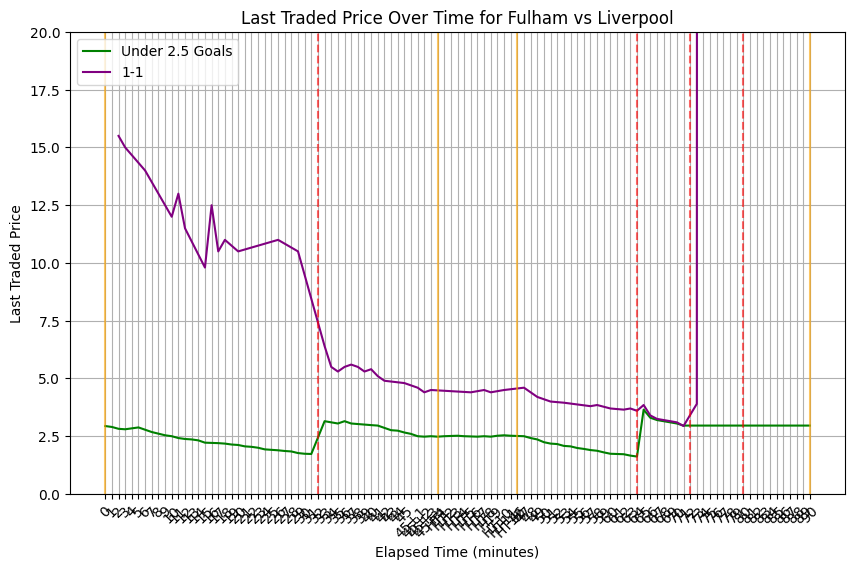

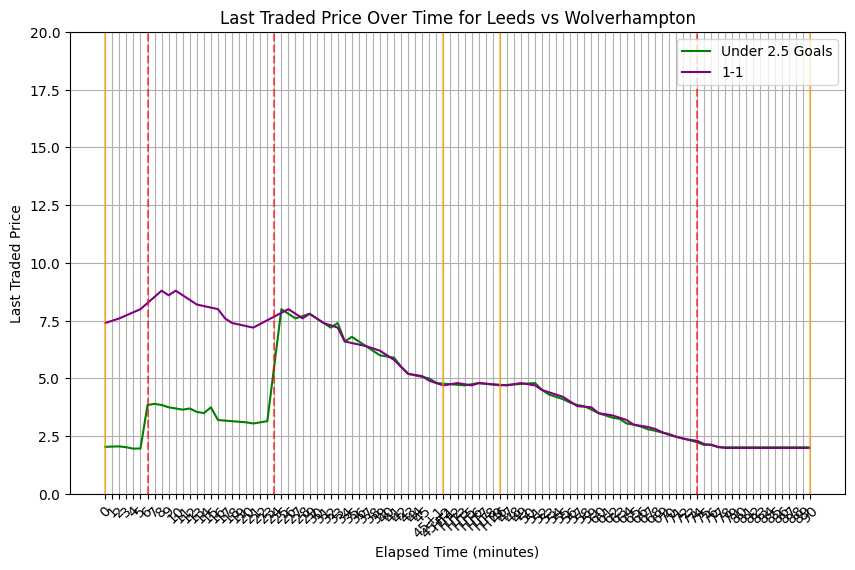

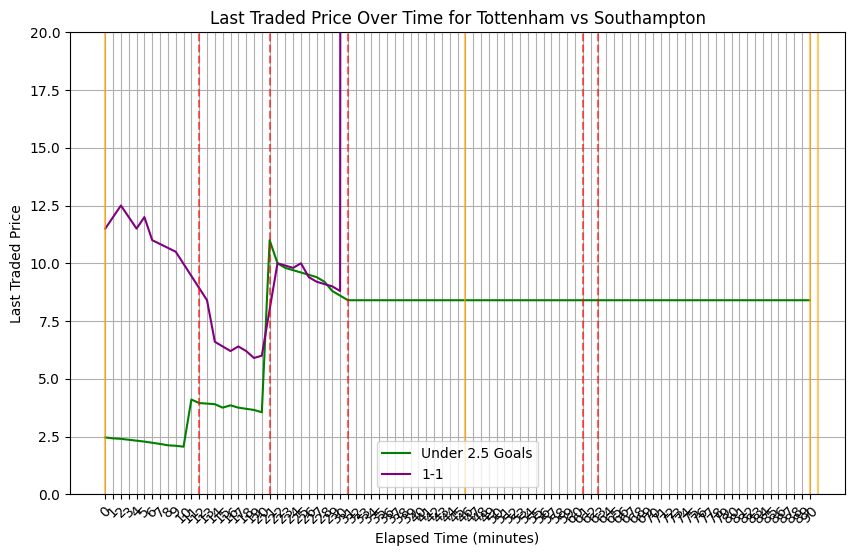

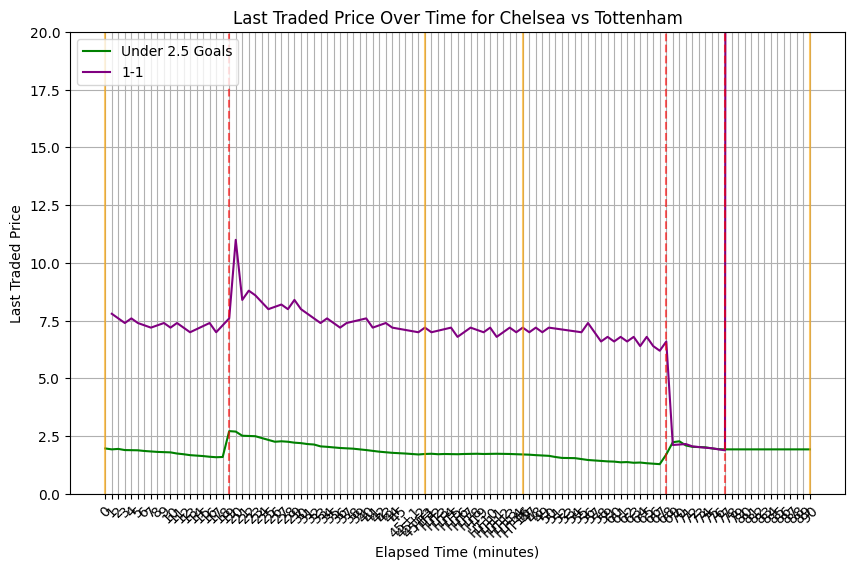

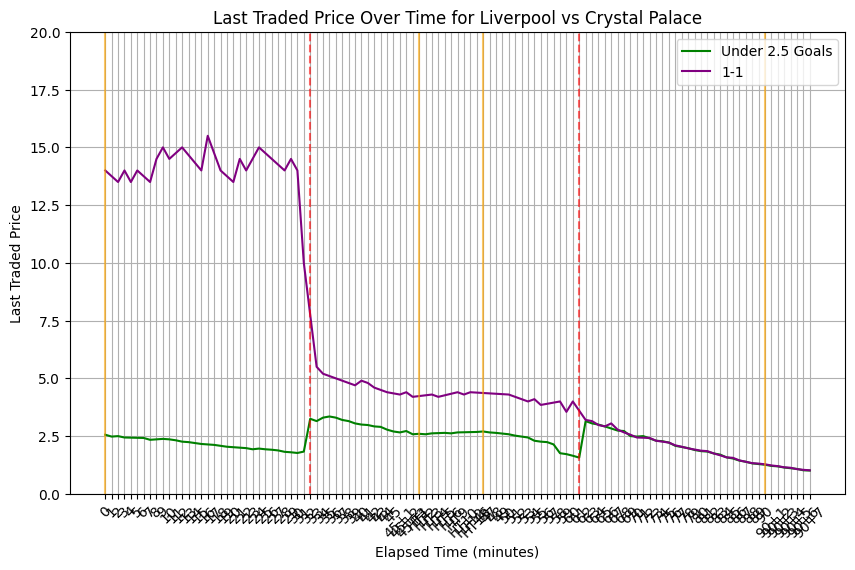

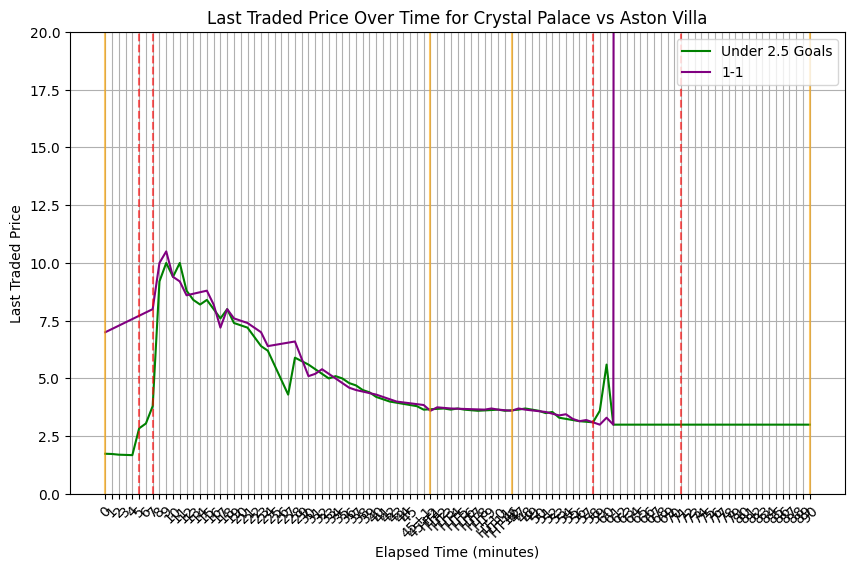

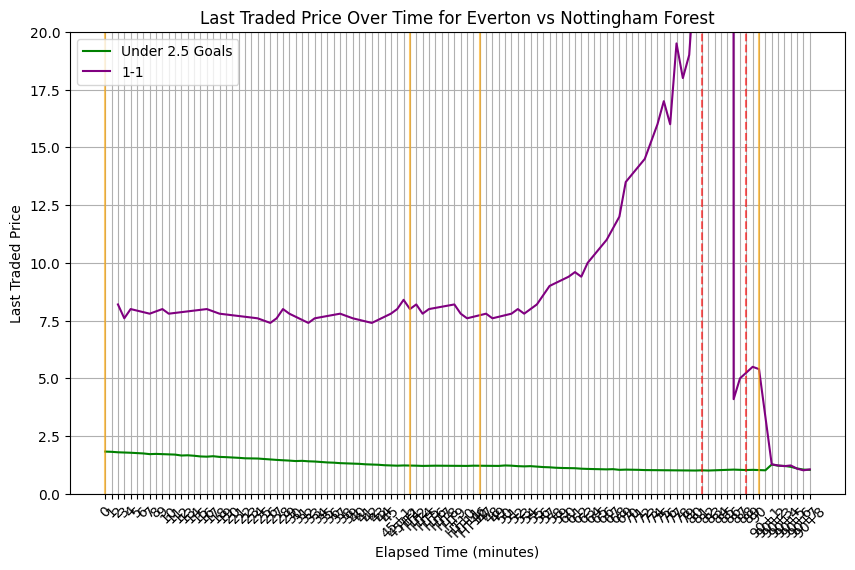

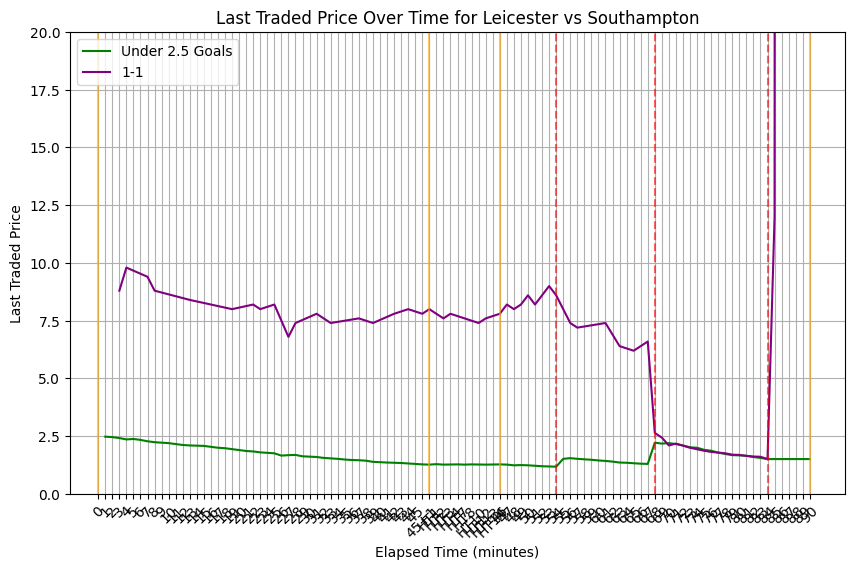

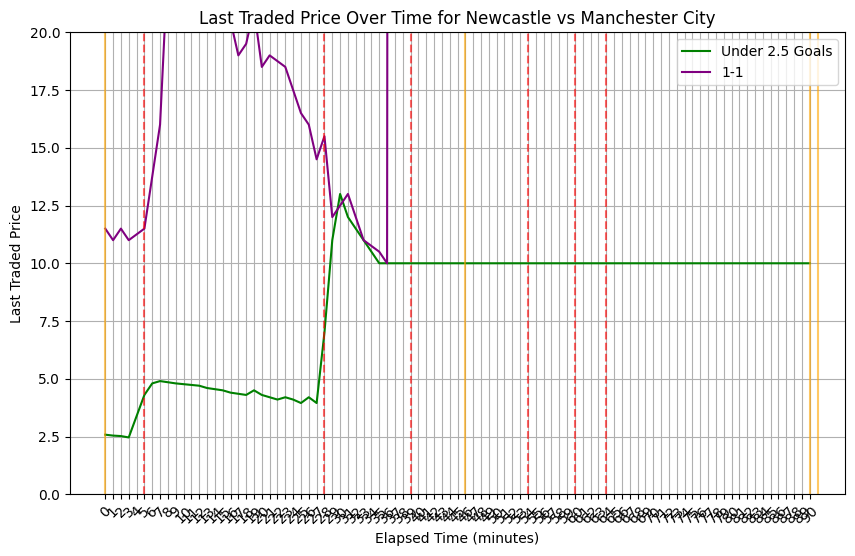

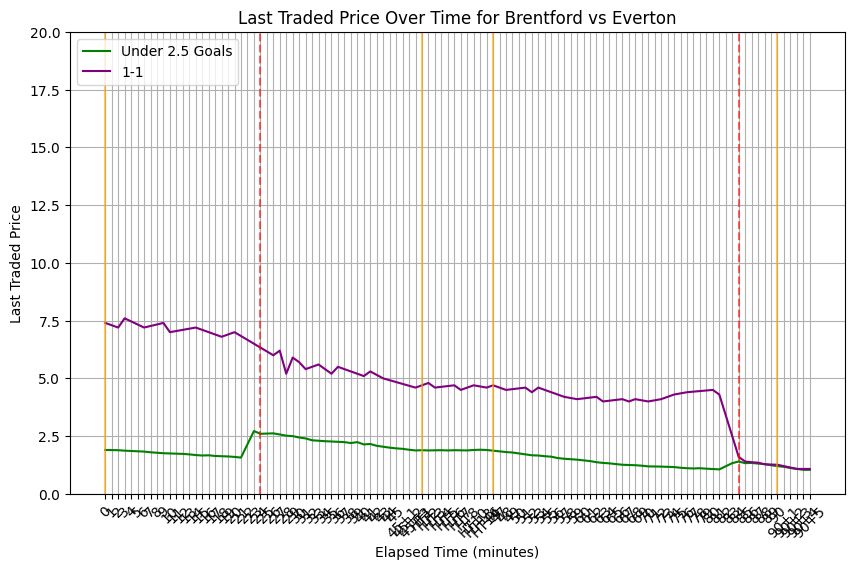

In [ ]:

generate_graphs(zipped_matches[:10],df2)

In [178]:
#function to change odds to 1000 once market is closed
def cmfill(df,col_name):
    last_valid_idx = df[col_name].last_valid_index()
    if last_valid_idx is not None:
        df.loc[last_valid_idx + 1:, col_name] = df.loc[last_valid_idx + 1:, col_name].fillna(1000)


In [2]:
#looking at other arb opps
def match_df(home,away,df):
    match_odds = df[(df['Home Team']==home)&(df['Away Team']==away)].copy()

    norm_mins = [(x,0,0) for x in range(0,91)]
    match_odds['time key'] = list(zip(match_odds['Elapsed Time'].astype(int),match_odds['Added Time'].astype(int),match_odds['Half Time'].astype(int)))
    extra_times = set(match_odds['time key'])-set(norm_mins)
    all_times = sorted(norm_mins+list(extra_times))
    new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
    new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

    under = match_odds[match_odds['Selection']=='Under 2.5 Goals'].copy()
    over = match_odds[match_odds['Selection']=='Over 2.5 Goals'].copy()
    exact_1_1 = match_odds[match_odds['Selection']=='1 - 1'].copy()
    exact_2_0 = match_odds[match_odds['Selection']=='2 - 0'].copy()
    exact_0_2 = match_odds[match_odds['Selection']=='0 - 2'].copy()
    exact_1_0 = match_odds[match_odds['Selection']=='1 - 0'].copy()
    exact_0_1 = match_odds[match_odds['Selection']=='0 - 1'].copy()
    exact_0_0 = match_odds[match_odds['Selection']=='0 - 0'].copy()

    new_df = new_df.merge(under[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'Under 2.5 Odds'})
    new_df['Under 2.5 Odds']=new_df['Under 2.5 Odds'].interpolate()

    new_df = new_df.merge(over[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'Over 2.5 Odds'})
    new_df['Over 2.5 Odds']=new_df['Over 2.5 Odds'].interpolate()

    new_df = new_df.merge(exact_1_1[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'1-1 Odds'})
    new_df['1-1 Odds']=new_df['1-1 Odds'].interpolate()
    new_df['1-1 Odds']=new_df['1-1 Odds'].fillna(1000)

    new_df = new_df.merge(exact_2_0[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'2-0 Odds'})
    new_df['2-0 Odds']=new_df['2-0 Odds'].interpolate()
    new_df['2-0 Odds']=new_df['2-0 Odds'].fillna(1000)

    new_df = new_df.merge(exact_0_2[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'0-2 Odds'})
    new_df['0-2 Odds']=new_df['0-2 Odds'].interpolate()
    new_df['0-2 Odds']=new_df['0-2 Odds'].fillna(1000)

    new_df = new_df.merge(exact_0_1[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'0-1 Odds'})
    new_df['0-1 Odds']=new_df['0-1 Odds'].interpolate()
    new_df['0-1 Odds']=new_df['0-1 Odds'].fillna(1000)

    new_df = new_df.merge(exact_1_0[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'1-0 Odds'})
    new_df['1-0 Odds']=new_df['1-0 Odds'].interpolate()
    new_df['1-0 Odds']=new_df['1-0 Odds'].fillna(1000)

    new_df = new_df.merge(exact_0_0[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'0-0 Odds'})
    last_valid_idx = new_df['0-0 Odds'].last_valid_index()
    new_df.loc[last_valid_idx + 1:, '0-0 Odds'] = df.loc[last_valid_idx + 1:, '0-0 Odds'].fillna(1000)
    #new_df['0-0 Odds']=new_df['0-0 Odds'].interpolate()
    #new_df['0-0 Odds']=new_df['0-0 Odds'].fillna(1000)

    new_df['Artificial under 2.5']=1/(1/new_df['1-1 Odds']+1/new_df['2-0 Odds']+1/new_df['0-2 Odds']+1/new_df['1-0 Odds']+1/new_df['0-1 Odds']+1/new_df['0-0 Odds'])



    goals2 = goals[(goals['Home Team']==home)&(goals['Away Team']==away)].copy()
    goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

    new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
    new_df['Score']=new_df['Score'].ffill().fillna('0-0')
    new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')
    new_df['synth under']=1/(new_df['Over 2.5 Odds']-1)+1

    def format_time(row):
        if row['Half Time']>0:
            return f'HT{row['Half Time']}'
        elif row['Added Time']>0:
            return f"{row['Elapsed Time']}+{row['Added Time']}"
        else: 
            return f"{row['Elapsed Time']}"

    new_df['plot label'] = new_df.apply(format_time,axis=1)
    
    
    return new_df
def plot_odds(new_df,home,away):
    plt.figure(figsize=(10, 6))
    plt.plot('plot label', 'Under 2.5 Odds', data =new_df ,linestyle='-', color='green', label='Under 2.5 Goals')
    #plt.plot('plot label', 'Over 2.5 Odds', data =new_df, linestyle='-', color='blue', label='Over 2.5 Goals')

    plt.plot('plot label', 'Artificial under 2.5', data =new_df, linestyle='-', color='purple', label='artificial basket')
    #plt.plot('plot label', 'synth under', data =new_df, linestyle='-', color='blue', label='synth under')

    #y_max = min(max(new_df['Over 2.5 Odds'].max(),new_df['Under 2.5 Odds'].max(),new_df['Artificial under 2.5'].max()),100)
    #y_range = np.arange(0,y_max,y_max//20)
    plt.xticks(new_df['plot label'],rotation=45)
    #plt.yticks(y_range)
    plt.grid()

    goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
    for g in goal_times:
        plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
    imp_times = ['0','HT1','46','90']

    for g in imp_times:
        plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)
    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Last Traded Price')
    plt.title(f'Last Traded Price Over Time for {home} vs {away}')
    plt.legend()
    plt.ylim(bottom = 0, top=20)
    


In [1]:
match_df('Leeds','Wolverhampton',df).head(20)


NameError: name 'match_df' is not defined

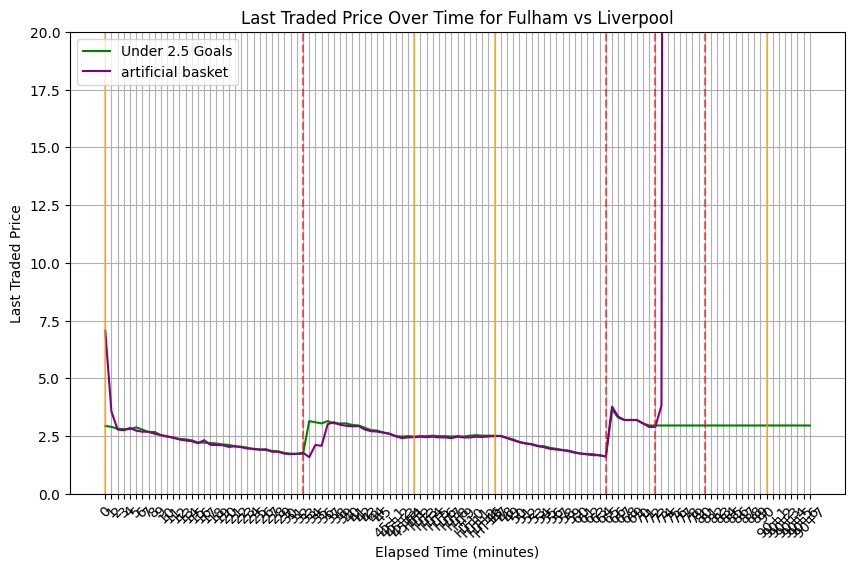

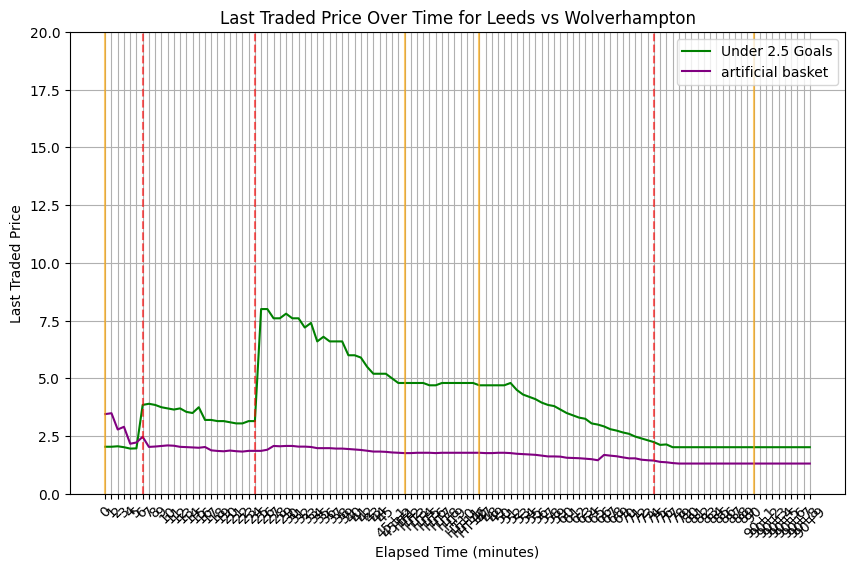

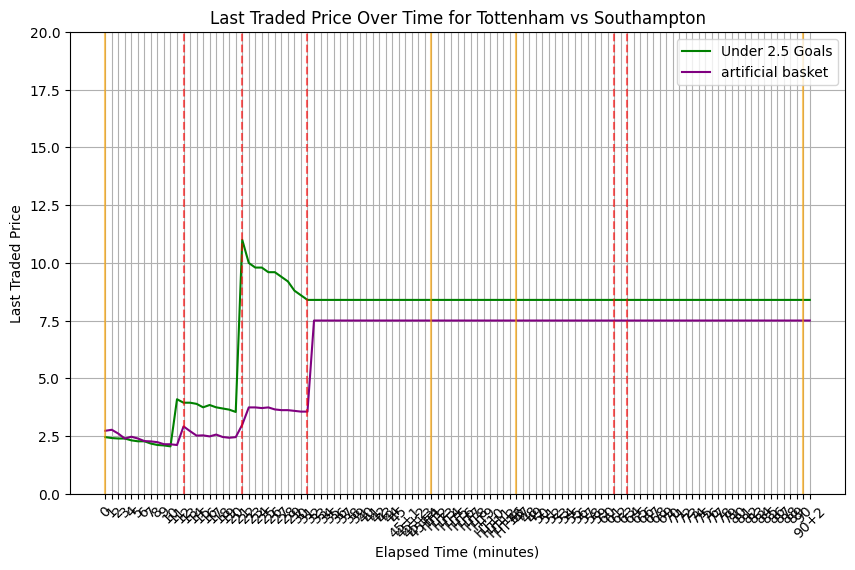

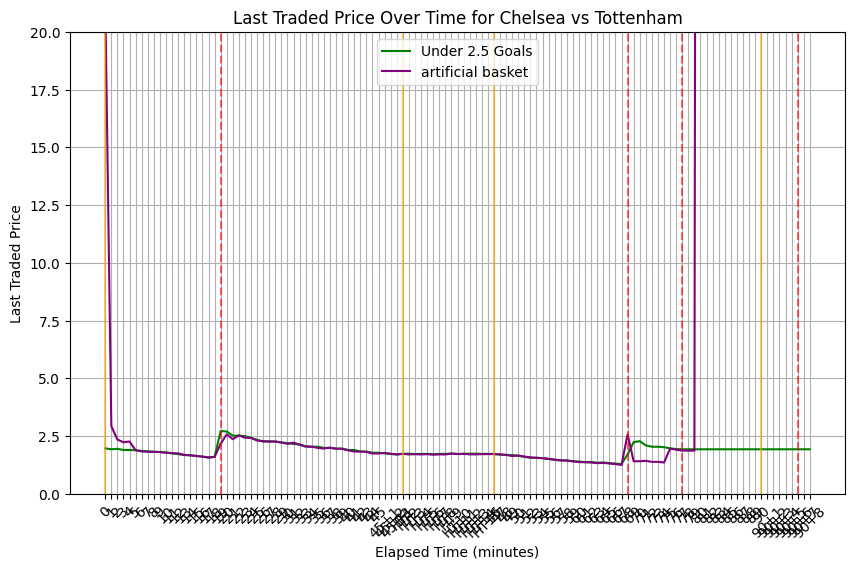

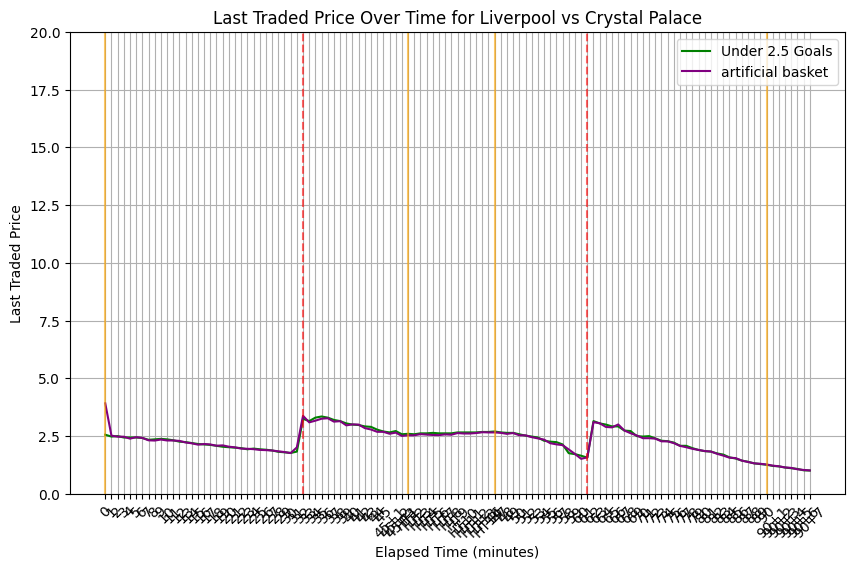

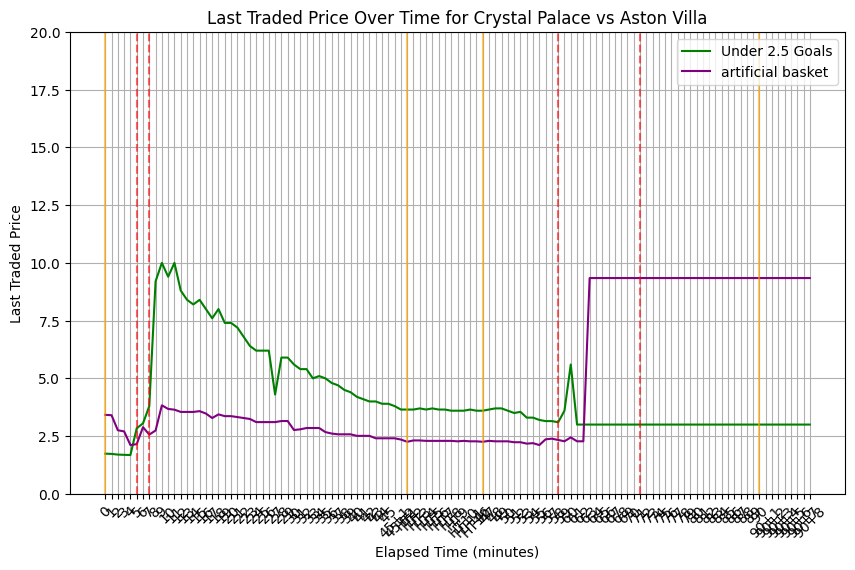

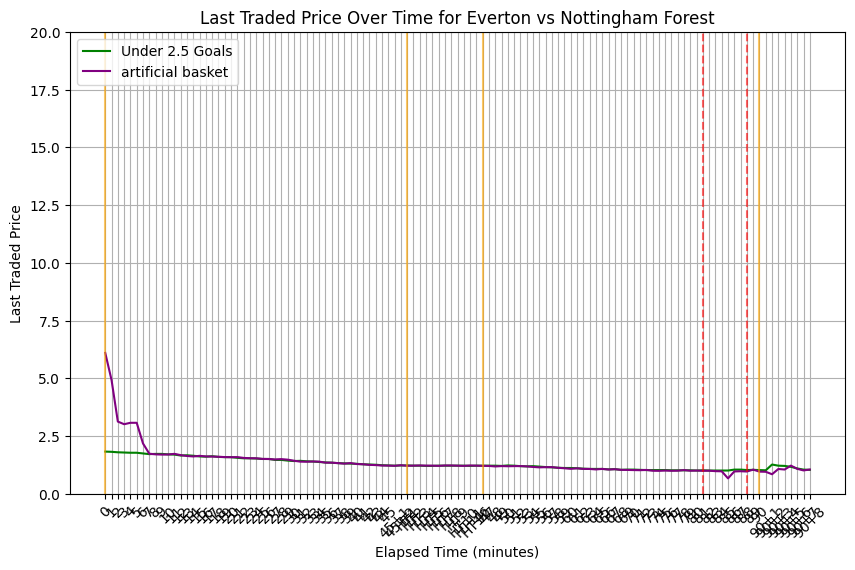

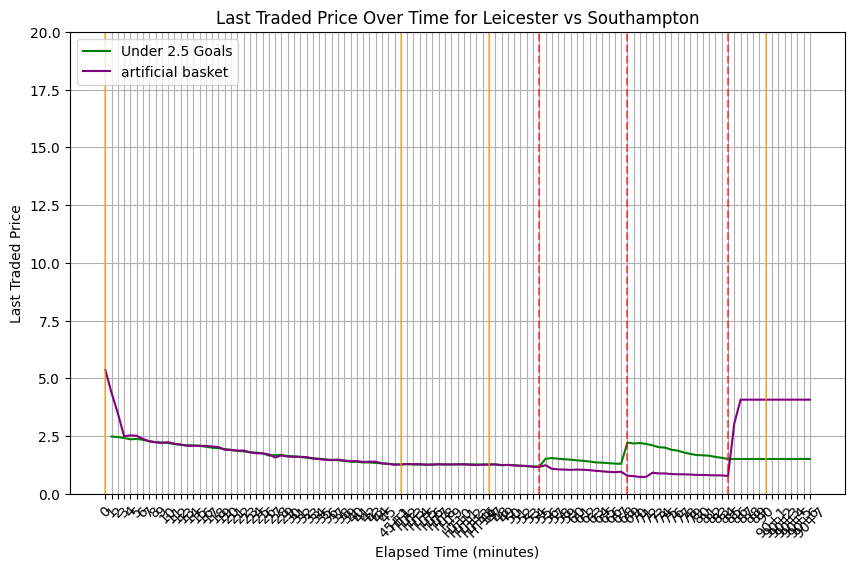

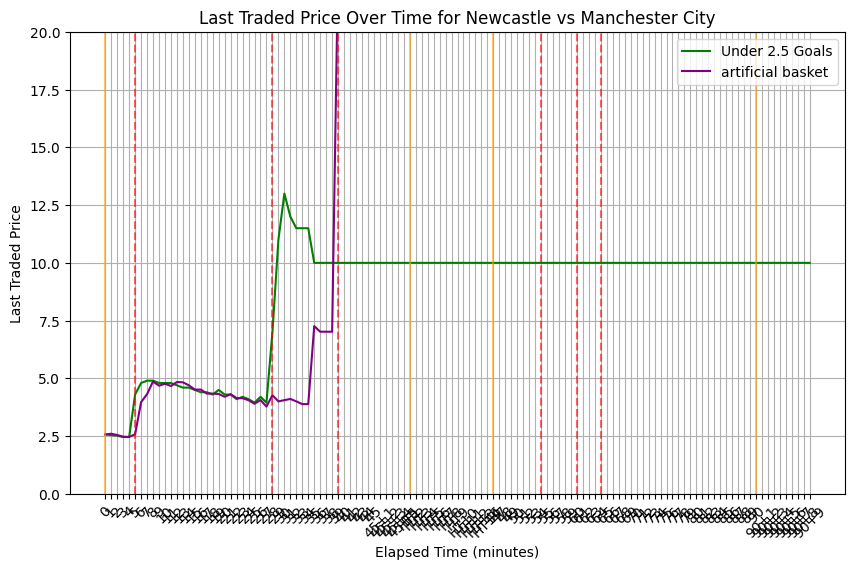

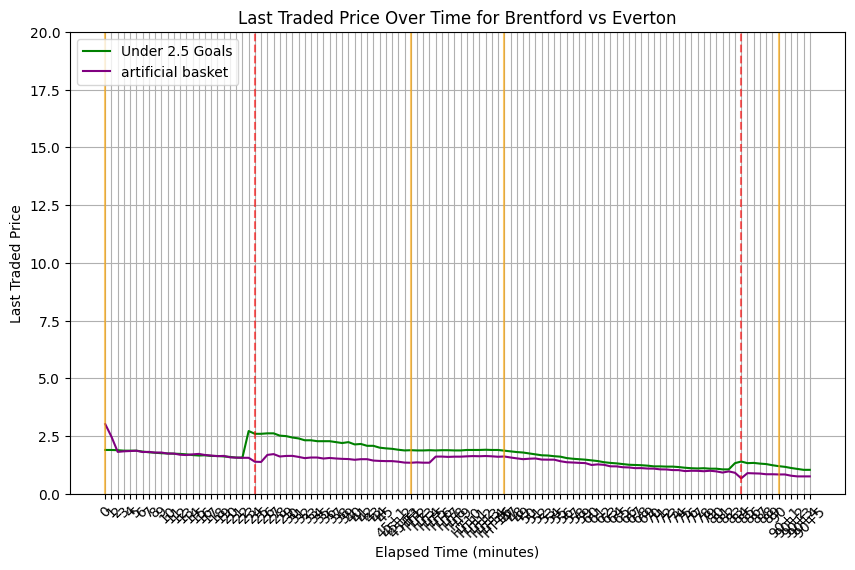

In [164]:
generate_graphs(zipped_matches[:10],df)

In [ ]:
#looking at other arb opps
def clamp_after_close(s,closed_val =1000):
    still_live = s.notna() & (s!= closed_val)
    if not still_live.any():
        return s.fillna(closed_val)
    last_live_idx = still_live[::-1].idxmax()
    print(last_live_idx)
    #after_close = s.index > last_live_idx
    s.loc[last_live_idx+1:]=closed_val

def match_df2(home,away,df):
    match_odds = df[(df['Home Team']==home)&(df['Away Team']==away)].copy()

    norm_mins = [(x,0,0) for x in range(0,91)]
    match_odds['time key'] = list(zip(match_odds['Elapsed Time'].astype(int),match_odds['Added Time'].astype(int),match_odds['Half Time'].astype(int)))
    extra_times = set(match_odds['time key'])-set(norm_mins)
    all_times = sorted(norm_mins+list(extra_times))
    new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
    new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

    
    under = match_odds[match_odds['Selection']=='Under 2.5 Goals'].copy()
    over = match_odds[match_odds['Selection']=='Over 2.5 Goals'].copy()
    exact_1_1 = match_odds[match_odds['Selection']=='1 - 1'].copy()
    exact_2_0 = match_odds[match_odds['Selection']=='2 - 0'].copy()
    exact_0_2 = match_odds[match_odds['Selection']=='0 - 2'].copy()
    exact_1_0 = match_odds[match_odds['Selection']=='1 - 0'].copy()
    exact_0_1 = match_odds[match_odds['Selection']=='0 - 1'].copy()
    exact_0_0 = match_odds[match_odds['Selection']=='0 - 0'].copy()

    markets = {'Under 2.5 Odds':under,'Over 2.5 Odds':over,'1-1 Odds':exact_1_1,'2-0 Odds':exact_2_0,'0-2 Odds':exact_0_2,'1-0 Odds':exact_1_0,'0-1 Odds':exact_0_1,'0-0 Odds':exact_0_0}
    for market in markets:
        new_df = new_df.merge(markets[market][['time key','Last Traded Price']],on='time key',how ='left')
        new_df = new_df.rename(columns={'Last Traded Price':market})
        still_live = new_df[market].notna() & (new_df[market]!= 1000)
        if still_live.any():
            last_live_idx = still_live[::-1].idxmax()
            new_df.loc[last_live_idx+1:,market]= 1000
        new_df[market]=new_df[market].ffill()
        new_df[market]=new_df[market].bfill()



    new_df['Artificial under 2.5']=1/(1/new_df['1-1 Odds']+1/new_df['2-0 Odds']+1/new_df['0-2 Odds']+1/new_df['1-0 Odds']+1/new_df['0-1 Odds']+1/new_df['0-0 Odds'])



    goals2 = goals[(goals['Home Team']==home)&(goals['Away Team']==away)].copy()
    goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

    new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
    new_df['Score']=new_df['Score'].ffill().fillna('0-0')
    new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')

    def format_time(row):
        if row['Half Time']>0:
            return f'HT{row['Half Time']}'
        elif row['Added Time']>0:
            return f"{row['Elapsed Time']}+{row['Added Time']}"
        else: 
            return f"{row['Elapsed Time']}"

    new_df['plot label'] = new_df.apply(format_time,axis=1)
    
    
    return new_df

match_df2('Crystal Palace', 'Aston Villa',df).head(30)


,Elapsed Time,Added Time,Half Time,time key,Under 2.5 Odds,Over 2.5 Odds,1-1 Odds,2-0 Odds,0-2 Odds,1-0 Odds,0-1 Odds,0-0 Odds,Artificial under 2.5,Goal Scored,Player,Goal Type,Score,plot label
0,0,0,0,"(0, 0, 0)",1.74,2.28,7.0,14.5,19.5,1000.0,10.5,9.8,2.167394,No,NaN,NaN,0-0,0
1,1,0,0,"(1, 0, 0)",1.73,2.36,7.0,14.5,19.0,1000.0,10.5,9.8,2.161073,No,NaN,NaN,0-0,1
2,2,0,0,"(2, 0, 0)",1.70,2.40,7.0,14.5,18.5,1000.0,10.5,9.8,2.154450,No,NaN,NaN,0-0,2
3,3,0,0,"(3, 0, 0)",1.69,2.42,7.0,14.5,18.5,1000.0,9.8,9.8,2.123330,No,NaN,NaN,0-0,3
4,4,0,0,"(4, 0, 0)",1.68,2.44,7.0,14.5,18.5,1000.0,9.6,9.8,2.113789,No,NaN,NaN,0-0,4
5,5,0,0,"(5, 0, 0)",2.84,1.55,7.0,16.5,18.5,1000.0,9.6,1000.0,2.749640,Yes,Ollie Watkins,Regular goal,0-1,5
6,6,0,0,"(6, 0, 0)",3.05,1.49,7.0,1000.0,18.5,1000.0,11.5,1000.0,3.485927,No,NaN,NaN,0-1,6
7,7,0,0,"(7, 0, 0)",3.80,1.32,8.0,1000.0,9.8,1000.0,10.0,1000.0,3.029928,Yes,Wilfried Zaha,Regular goal,1-1,7
8,8,0,0,"(8, 0, 0)",9.20,1.12,10.0,1000.0,1000.0,1000.0,1000.0,1000.0,9.523810,No,NaN,NaN,1-1,8
9,9,0,0,"(9, 0, 0)",10.00,1.12,10.5,1000.0,1000.0,1000.0,1000.0,1000.0,9.976247,No,NaN,NaN,1-1,9


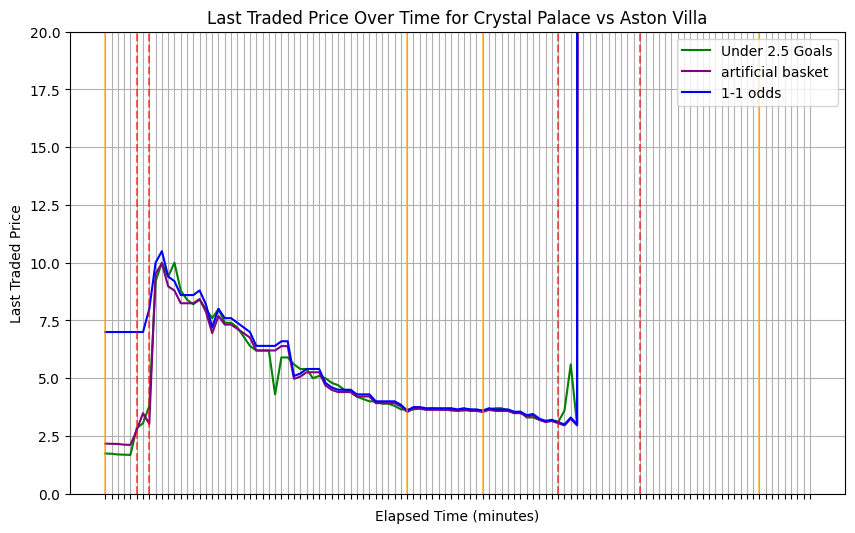

In [66]:
def plot_odds(new_df,home,away):
    plt.figure(figsize=(10, 6))
    plt.plot('plot label', 'Under 2.5 Odds', data =new_df ,linestyle='-', color='green', label='Under 2.5 Goals')
    #plt.plot('plot label', 'Over 2.5 Odds', data =new_df, linestyle='-', color='blue', label='Over 2.5 Goals')

    plt.plot('plot label', 'Artificial under 2.5', data =new_df, linestyle='-', color='purple', label='artificial basket')
    plt.plot('plot label', '1-1 Odds', data =new_df, linestyle='-', color='blue', label='1-1 odds')

    #y_max = min(max(new_df['Over 2.5 Odds'].max(),new_df['Under 2.5 Odds'].max(),new_df['Artificial under 2.5'].max()),100)
    #y_range = np.arange(0,y_max,y_max//20)
    plt.xticks(new_df['plot label'],'',rotation=45)
    #plt.yticks(y_range)
    plt.grid()

    goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
    for g in goal_times:
        plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
    imp_times = ['0','HT1','46','90']

    for g in imp_times:
        plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)
    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Last Traded Price')
    plt.title(f'Last Traded Price Over Time for {home} vs {away}')
    plt.legend()
    plt.ylim(bottom = 0, top=20)

plot_odds(match_df2('Crystal Palace', 'Aston Villa',df),'Crystal Palace', 'Aston Villa')